In [347]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [175]:
df = pd.read_csv('YourCabs.csv')

In [176]:
df.head()

,id,user_id,vehicle_model_id,travel_type_id,package_id,from_area_id,to_area_id,from_city_id,to_city_id,from_date,online_booking,mobile_site_booking,booking_created,from_lat,from_long,to_lat,to_long,Car_Cancellation
0,132512,22177,28,2,NaN,83.0,448.0,NaN,NaN,01-01-2013 02:00,0,0,01-01-2013 01:39,12.924150,77.672290,12.927320,77.635750,0
1,132513,21413,12,2,NaN,1010.0,540.0,NaN,NaN,01-01-2013 09:00,0,0,01-01-2013 02:25,12.966910,77.749350,12.927680,77.626640,0
2,132514,22178,12,2,NaN,1301.0,1034.0,NaN,NaN,01-01-2013 03:30,0,0,01-01-2013 03:08,12.937222,77.626915,13.047926,77.597766,0
3,132515,13034,12,2,NaN,768.0,398.0,NaN,NaN,01-01-2013 05:45,0,0,01-01-2013 04:39,12.989990,77.553320,12.971430,77.639140,0
4,132517,22180,12,2,NaN,1365.0,849.0,NaN,NaN,01-01-2013 09:00,0,0,01-01-2013 07:53,12.845653,77.677925,12.954340,77.600720,0


In [177]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43431 entries, 0 to 43430
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   43431 non-null  int64  
 1   user_id              43431 non-null  int64  
 2   vehicle_model_id     43431 non-null  int64  
 3   travel_type_id       43431 non-null  int64  
 4   package_id           7550 non-null   float64
 5   from_area_id         43343 non-null  float64
 6   to_area_id           34293 non-null  float64
 7   from_city_id         16345 non-null  float64
 8   to_city_id           1588 non-null   float64
 9   from_date            43431 non-null  object 
 10  online_booking       43431 non-null  int64  
 11  mobile_site_booking  43431 non-null  int64  
 12  booking_created      43431 non-null  object 
 13  from_lat             43338 non-null  float64
 14  from_long            43338 non-null  float64
 15  to_lat               34293 non-null 

In [178]:
df.drop(columns=['id','user_id'],inplace=True)

In [179]:
df.head()

,vehicle_model_id,travel_type_id,package_id,from_area_id,to_area_id,from_city_id,to_city_id,from_date,online_booking,mobile_site_booking,booking_created,from_lat,from_long,to_lat,to_long,Car_Cancellation
0,28,2,NaN,83.0,448.0,NaN,NaN,01-01-2013 02:00,0,0,01-01-2013 01:39,12.924150,77.672290,12.927320,77.635750,0
1,12,2,NaN,1010.0,540.0,NaN,NaN,01-01-2013 09:00,0,0,01-01-2013 02:25,12.966910,77.749350,12.927680,77.626640,0
2,12,2,NaN,1301.0,1034.0,NaN,NaN,01-01-2013 03:30,0,0,01-01-2013 03:08,12.937222,77.626915,13.047926,77.597766,0
3,12,2,NaN,768.0,398.0,NaN,NaN,01-01-2013 05:45,0,0,01-01-2013 04:39,12.989990,77.553320,12.971430,77.639140,0
4,12,2,NaN,1365.0,849.0,NaN,NaN,01-01-2013 09:00,0,0,01-01-2013 07:53,12.845653,77.677925,12.954340,77.600720,0


In [180]:
df['is_VMID_12']= pd.get_dummies(df['vehicle_model_id'].astype('category'))[[12]].astype('int')

In [181]:
df.head()

,vehicle_model_id,travel_type_id,package_id,from_area_id,to_area_id,from_city_id,to_city_id,from_date,online_booking,mobile_site_booking,booking_created,from_lat,from_long,to_lat,to_long,Car_Cancellation,is_VMID_12
0,28,2,NaN,83.0,448.0,NaN,NaN,01-01-2013 02:00,0,0,01-01-2013 01:39,12.924150,77.672290,12.927320,77.635750,0,0
1,12,2,NaN,1010.0,540.0,NaN,NaN,01-01-2013 09:00,0,0,01-01-2013 02:25,12.966910,77.749350,12.927680,77.626640,0,1
2,12,2,NaN,1301.0,1034.0,NaN,NaN,01-01-2013 03:30,0,0,01-01-2013 03:08,12.937222,77.626915,13.047926,77.597766,0,1
3,12,2,NaN,768.0,398.0,NaN,NaN,01-01-2013 05:45,0,0,01-01-2013 04:39,12.989990,77.553320,12.971430,77.639140,0,1
4,12,2,NaN,1365.0,849.0,NaN,NaN,01-01-2013 09:00,0,0,01-01-2013 07:53,12.845653,77.677925,12.954340,77.600720,0,1


In [182]:
df.drop(columns=['vehicle_model_id'],axis=1,inplace=True)

In [183]:
df.head()

,travel_type_id,package_id,from_area_id,to_area_id,from_city_id,to_city_id,from_date,online_booking,mobile_site_booking,booking_created,from_lat,from_long,to_lat,to_long,Car_Cancellation,is_VMID_12
0,2,NaN,83.0,448.0,NaN,NaN,01-01-2013 02:00,0,0,01-01-2013 01:39,12.924150,77.672290,12.927320,77.635750,0,0
1,2,NaN,1010.0,540.0,NaN,NaN,01-01-2013 09:00,0,0,01-01-2013 02:25,12.966910,77.749350,12.927680,77.626640,0,1
2,2,NaN,1301.0,1034.0,NaN,NaN,01-01-2013 03:30,0,0,01-01-2013 03:08,12.937222,77.626915,13.047926,77.597766,0,1
3,2,NaN,768.0,398.0,NaN,NaN,01-01-2013 05:45,0,0,01-01-2013 04:39,12.989990,77.553320,12.971430,77.639140,0,1
4,2,NaN,1365.0,849.0,NaN,NaN,01-01-2013 09:00,0,0,01-01-2013 07:53,12.845653,77.677925,12.954340,77.600720,0,1


In [184]:
df.travel_type_id.unique()

array([2, 1, 3], dtype=int64)

In [185]:
df_ttid_1 = df.loc[df['travel_type_id']==1]
df_ttid_1.head()

,travel_type_id,package_id,from_area_id,to_area_id,from_city_id,to_city_id,from_date,online_booking,mobile_site_booking,booking_created,from_lat,from_long,to_lat,to_long,Car_Cancellation,is_VMID_12
6,1,NaN,571.0,NaN,15.0,108.0,01-01-2013 09:45,0,0,01-01-2013 09:21,12.951850,77.696420,NaN,NaN,0,1
17,1,NaN,1383.0,NaN,NaN,32.0,01-12-2013 08:00,1,0,01-01-2013 12:17,12.930451,77.685822,NaN,NaN,0,0
24,1,NaN,515.0,NaN,15.0,32.0,01-05-2013 08:30,0,0,01-01-2013 14:40,12.978960,77.673450,NaN,NaN,0,0
158,1,NaN,136.0,NaN,1.0,152.0,01-04-2013 09:30,1,0,01-03-2013 12:19,12.907960,77.624180,NaN,NaN,0,0
216,1,NaN,1118.0,NaN,NaN,32.0,01-06-2013 07:30,1,0,01-04-2013 09:32,12.930220,77.560390,NaN,NaN,0,0


In [186]:
df_ttid_2 = df.loc[df['travel_type_id']==2]
df_ttid_2.head()

,travel_type_id,package_id,from_area_id,to_area_id,from_city_id,to_city_id,from_date,online_booking,mobile_site_booking,booking_created,from_lat,from_long,to_lat,to_long,Car_Cancellation,is_VMID_12
0,2,NaN,83.0,448.0,NaN,NaN,01-01-2013 02:00,0,0,01-01-2013 01:39,12.924150,77.672290,12.927320,77.635750,0,0
1,2,NaN,1010.0,540.0,NaN,NaN,01-01-2013 09:00,0,0,01-01-2013 02:25,12.966910,77.749350,12.927680,77.626640,0,1
2,2,NaN,1301.0,1034.0,NaN,NaN,01-01-2013 03:30,0,0,01-01-2013 03:08,12.937222,77.626915,13.047926,77.597766,0,1
3,2,NaN,768.0,398.0,NaN,NaN,01-01-2013 05:45,0,0,01-01-2013 04:39,12.989990,77.553320,12.971430,77.639140,0,1
4,2,NaN,1365.0,849.0,NaN,NaN,01-01-2013 09:00,0,0,01-01-2013 07:53,12.845653,77.677925,12.954340,77.600720,0,1


In [187]:
df_ttid_3 = df.loc[df['travel_type_id']==3]
df_ttid_3.head()

,travel_type_id,package_id,from_area_id,to_area_id,from_city_id,to_city_id,from_date,online_booking,mobile_site_booking,booking_created,from_lat,from_long,to_lat,to_long,Car_Cancellation,is_VMID_12
8,3,2.0,448.0,NaN,NaN,NaN,01-01-2013 16:00,0,0,01-01-2013 09:44,12.927320,77.635750,NaN,NaN,0,0
20,3,2.0,471.0,NaN,NaN,NaN,01-01-2013 14:30,0,0,01-01-2013 12:52,13.018540,77.635240,NaN,NaN,0,0
23,3,1.0,1286.0,NaN,NaN,NaN,01-01-2013 16:30,0,0,01-01-2013 14:39,12.973448,77.620320,NaN,NaN,0,1
34,3,1.0,1323.0,NaN,NaN,NaN,01-01-2013 20:00,1,0,01-01-2013 17:25,12.869805,77.653211,NaN,NaN,0,1
47,3,2.0,142.0,NaN,NaN,NaN,01-02-2013 03:00,0,0,01-01-2013 19:37,12.912810,77.609230,NaN,NaN,0,1


In [188]:
df_ttid_1.head()

,travel_type_id,package_id,from_area_id,to_area_id,from_city_id,to_city_id,from_date,online_booking,mobile_site_booking,booking_created,from_lat,from_long,to_lat,to_long,Car_Cancellation,is_VMID_12
6,1,NaN,571.0,NaN,15.0,108.0,01-01-2013 09:45,0,0,01-01-2013 09:21,12.951850,77.696420,NaN,NaN,0,1
17,1,NaN,1383.0,NaN,NaN,32.0,01-12-2013 08:00,1,0,01-01-2013 12:17,12.930451,77.685822,NaN,NaN,0,0
24,1,NaN,515.0,NaN,15.0,32.0,01-05-2013 08:30,0,0,01-01-2013 14:40,12.978960,77.673450,NaN,NaN,0,0
158,1,NaN,136.0,NaN,1.0,152.0,01-04-2013 09:30,1,0,01-03-2013 12:19,12.907960,77.624180,NaN,NaN,0,0
216,1,NaN,1118.0,NaN,NaN,32.0,01-06-2013 07:30,1,0,01-04-2013 09:32,12.930220,77.560390,NaN,NaN,0,0


In [189]:
df_ttid_1.isnull().sum()

travel_type_id            0
package_id             1589
from_area_id             88
to_area_id             1588
from_city_id            196
to_city_id                1
from_date                 0
online_booking            0
mobile_site_booking       0
booking_created           0
from_lat                 93
from_long                93
to_lat                 1588
to_long                1588
Car_Cancellation          0
is_VMID_12                0
dtype: int64

In [190]:
df_ttid_1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1589 entries, 6 to 43407
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   travel_type_id       1589 non-null   int64  
 1   package_id           0 non-null      float64
 2   from_area_id         1501 non-null   float64
 3   to_area_id           1 non-null      float64
 4   from_city_id         1393 non-null   float64
 5   to_city_id           1588 non-null   float64
 6   from_date            1589 non-null   object 
 7   online_booking       1589 non-null   int64  
 8   mobile_site_booking  1589 non-null   int64  
 9   booking_created      1589 non-null   object 
 10  from_lat             1496 non-null   float64
 11  from_long            1496 non-null   float64
 12  to_lat               1 non-null      float64
 13  to_long              1 non-null      float64
 14  Car_Cancellation     1589 non-null   int64  
 15  is_VMID_12           1589 non-null   int32

In [191]:
df_ttid_1.columns

Index(['travel_type_id', 'package_id', 'from_area_id', 'to_area_id',
       'from_city_id', 'to_city_id', 'from_date', 'online_booking',
       'mobile_site_booking', 'booking_created', 'from_lat', 'from_long',
       'to_lat', 'to_long', 'Car_Cancellation', 'is_VMID_12'],
      dtype='object')

In [192]:
df_ttid_1 = df_ttid_1.drop(columns=['travel_type_id','package_id','to_area_id','from_lat', 'from_long',
       'to_lat', 'to_long'],axis=1)

In [193]:
df_ttid_1.head()

,from_area_id,from_city_id,to_city_id,from_date,online_booking,mobile_site_booking,booking_created,Car_Cancellation,is_VMID_12
6,571.0,15.0,108.0,01-01-2013 09:45,0,0,01-01-2013 09:21,0,1
17,1383.0,NaN,32.0,01-12-2013 08:00,1,0,01-01-2013 12:17,0,0
24,515.0,15.0,32.0,01-05-2013 08:30,0,0,01-01-2013 14:40,0,0
158,136.0,1.0,152.0,01-04-2013 09:30,1,0,01-03-2013 12:19,0,0
216,1118.0,NaN,32.0,01-06-2013 07:30,1,0,01-04-2013 09:32,0,0


In [194]:
df_ttid_1.isnull().sum()

from_area_id            88
from_city_id           196
to_city_id               1
from_date                0
online_booking           0
mobile_site_booking      0
booking_created          0
Car_Cancellation         0
is_VMID_12               0
dtype: int64

In [195]:
df_ttid_1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1589 entries, 6 to 43407
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   from_area_id         1501 non-null   float64
 1   from_city_id         1393 non-null   float64
 2   to_city_id           1588 non-null   float64
 3   from_date            1589 non-null   object 
 4   online_booking       1589 non-null   int64  
 5   mobile_site_booking  1589 non-null   int64  
 6   booking_created      1589 non-null   object 
 7   Car_Cancellation     1589 non-null   int64  
 8   is_VMID_12           1589 non-null   int32  
dtypes: float64(3), int32(1), int64(3), object(2)
memory usage: 117.9+ KB


In [196]:
def cat(df,cols):
    for col in cols:
        if df[col].dtype != 'O':
            df[col] = df[col].astype('category')
    return df

In [197]:
cat(df_ttid_1,['from_area_id','from_city_id','to_city_id'])

,from_area_id,from_city_id,to_city_id,from_date,online_booking,mobile_site_booking,booking_created,Car_Cancellation,is_VMID_12
6,571.0,15.0,108.0,01-01-2013 09:45,0,0,01-01-2013 09:21,0,1
17,1383.0,NaN,32.0,01-12-2013 08:00,1,0,01-01-2013 12:17,0,0
24,515.0,15.0,32.0,01-05-2013 08:30,0,0,01-01-2013 14:40,0,0
158,136.0,1.0,152.0,01-04-2013 09:30,1,0,01-03-2013 12:19,0,0
216,1118.0,NaN,32.0,01-06-2013 07:30,1,0,01-04-2013 09:32,0,0
...,...,...,...,...,...,...,...,...,...
43342,393.0,15.0,191.0,11/23/2013 22:00,1,0,11/23/2013 17:54,0,1
43385,119.0,15.0,146.0,11/29/2013 14:00,1,0,11/23/2013 23:24,0,0
43386,1281.0,15.0,32.0,11/24/2013 7:30,1,0,11/23/2013 23:44,0,1
43393,393.0,15.0,116.0,11/24/2013 10:30,0,0,11/24/2013 7:14,0,1


In [198]:
df_ttid_1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1589 entries, 6 to 43407
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   from_area_id         1501 non-null   category
 1   from_city_id         1393 non-null   category
 2   to_city_id           1588 non-null   category
 3   from_date            1589 non-null   object  
 4   online_booking       1589 non-null   int64   
 5   mobile_site_booking  1589 non-null   int64   
 6   booking_created      1589 non-null   object  
 7   Car_Cancellation     1589 non-null   int64   
 8   is_VMID_12           1589 non-null   int32   
dtypes: category(3), int32(1), int64(3), object(2)
memory usage: 102.4+ KB


In [199]:
df_ttid_1.describe(include=['category'])

,from_area_id,from_city_id,to_city_id
count,1501.0,1393.0,1588.0
unique,297.0,3.0,116.0
top,393.0,15.0,32.0
freq,257.0,1281.0,475.0


In [200]:
df_ttid_1['from_area_id'] = df_ttid_1['from_area_id'].fillna(393)

In [201]:
df_ttid_1['from_city_id'] = df_ttid_1['from_city_id'].fillna(15)
df_ttid_1['to_city_id'] = df_ttid_1['to_city_id'].fillna(32)


In [202]:
df_ttid_1.isna().sum()

from_area_id           0
from_city_id           0
to_city_id             0
from_date              0
online_booking         0
mobile_site_booking    0
booking_created        0
Car_Cancellation       0
is_VMID_12             0
dtype: int64

In [203]:
from_area_id_cancellation_perc = df_ttid_1[['from_area_id','Car_Cancellation']].groupby('from_area_id').mean()['Car_Cancellation']

In [204]:
from_area_id_cancellation_perc.head(10)

from_area_id
2.0     0.000000
24.0    0.000000
25.0    0.000000
49.0    0.000000
58.0    0.000000
61.0    0.166667
62.0    0.500000
83.0    0.034483
85.0    0.000000
87.0    0.000000
Name: Car_Cancellation, dtype: float64

In [205]:
df_ttid_1['from_area_id_cancellation_perc'] = df_ttid_1['from_area_id'].map(from_area_id_cancellation_perc)

In [206]:
df_ttid_1.head()

,from_area_id,from_city_id,to_city_id,from_date,online_booking,mobile_site_booking,booking_created,Car_Cancellation,is_VMID_12,from_area_id_cancellation_perc
6,571.0,15.0,108.0,01-01-2013 09:45,0,0,01-01-2013 09:21,0,1,0.020408
17,1383.0,15.0,32.0,01-12-2013 08:00,1,0,01-01-2013 12:17,0,0,0.000000
24,515.0,15.0,32.0,01-05-2013 08:30,0,0,01-01-2013 14:40,0,0,0.000000
158,136.0,1.0,152.0,01-04-2013 09:30,1,0,01-03-2013 12:19,0,0,0.000000
216,1118.0,15.0,32.0,01-06-2013 07:30,1,0,01-04-2013 09:32,0,0,0.000000


In [207]:
df_ttid_1['city_route'] = df_ttid_1['from_city_id'].astype('int').astype('str') + '->' + df_ttid_1['to_city_id'].astype('int').astype('str')

In [208]:
df_ttid_1.head()

,from_area_id,from_city_id,to_city_id,from_date,online_booking,mobile_site_booking,booking_created,Car_Cancellation,is_VMID_12,from_area_id_cancellation_perc,city_route
6,571.0,15.0,108.0,01-01-2013 09:45,0,0,01-01-2013 09:21,0,1,0.020408,15->108
17,1383.0,15.0,32.0,01-12-2013 08:00,1,0,01-01-2013 12:17,0,0,0.000000,15->32
24,515.0,15.0,32.0,01-05-2013 08:30,0,0,01-01-2013 14:40,0,0,0.000000,15->32
158,136.0,1.0,152.0,01-04-2013 09:30,1,0,01-03-2013 12:19,0,0,0.000000,1->152
216,1118.0,15.0,32.0,01-06-2013 07:30,1,0,01-04-2013 09:32,0,0,0.000000,15->32


In [209]:
city_route_cancellation_perc = df_ttid_1[['city_route','Car_Cancellation']].groupby('city_route').mean()['Car_Cancellation']
df_ttid_1['city_route_cancellation_perc'] = df_ttid_1['city_route'].map(city_route_cancellation_perc)
df_ttid_1.head(10)

,from_area_id,from_city_id,to_city_id,from_date,online_booking,mobile_site_booking,booking_created,Car_Cancellation,is_VMID_12,from_area_id_cancellation_perc,city_route,city_route_cancellation_perc
6,571.0,15.0,108.0,01-01-2013 09:45,0,0,01-01-2013 09:21,0,1,0.020408,15->108,0.016129
17,1383.0,15.0,32.0,01-12-2013 08:00,1,0,01-01-2013 12:17,0,0,0.000000,15->32,0.017937
24,515.0,15.0,32.0,01-05-2013 08:30,0,0,01-01-2013 14:40,0,0,0.000000,15->32,0.017937
158,136.0,1.0,152.0,01-04-2013 09:30,1,0,01-03-2013 12:19,0,0,0.000000,1->152,0.000000
216,1118.0,15.0,32.0,01-06-2013 07:30,1,0,01-04-2013 09:32,0,0,0.000000,15->32,0.017937
233,293.0,15.0,32.0,01-05-2013 08:00,0,0,01-04-2013 12:43,0,0,0.000000,15->32,0.017937
234,912.0,1.0,32.0,01-05-2013 06:00,1,0,01-04-2013 12:51,0,0,0.000000,1->32,0.000000
243,410.0,15.0,29.0,01-09-2013 06:00,0,0,01-04-2013 14:40,0,0,0.000000,15->29,0.037037
328,393.0,15.0,32.0,01-05-2013 22:45,0,0,01-05-2013 15:29,0,1,0.008696,15->32,0.017937
332,396.0,15.0,32.0,01-06-2013 06:45,0,0,01-05-2013 16:24,0,1,0.076923,15->32,0.017937


In [210]:
df_ttid_1['from_area_id_cancellation'] = np.where(df_ttid_1['from_area_id_cancellation_perc'] >= 0.67, 'High',
        np.where(df_ttid_1['from_area_id_cancellation_perc'] < 0.33, 'Low',
                 'Medium'))

In [211]:
df_ttid_1.head()

,from_area_id,from_city_id,to_city_id,from_date,online_booking,mobile_site_booking,booking_created,Car_Cancellation,is_VMID_12,from_area_id_cancellation_perc,city_route,city_route_cancellation_perc,from_area_id_cancellation
6,571.0,15.0,108.0,01-01-2013 09:45,0,0,01-01-2013 09:21,0,1,0.020408,15->108,0.016129,Low
17,1383.0,15.0,32.0,01-12-2013 08:00,1,0,01-01-2013 12:17,0,0,0.000000,15->32,0.017937,Low
24,515.0,15.0,32.0,01-05-2013 08:30,0,0,01-01-2013 14:40,0,0,0.000000,15->32,0.017937,Low
158,136.0,1.0,152.0,01-04-2013 09:30,1,0,01-03-2013 12:19,0,0,0.000000,1->152,0.000000,Low
216,1118.0,15.0,32.0,01-06-2013 07:30,1,0,01-04-2013 09:32,0,0,0.000000,15->32,0.017937,Low


In [212]:
df_ttid_1['from_area_id_cancellation'].loc[df_ttid_1['from_area_id_cancellation_perc'] == 0] = 'Zero'
df_ttid_1.head()

C:\Users\naiko\AppData\Local\Temp\ipykernel_14164\4274189254.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ttid_1['from_area_id_cancellation'].loc[df_ttid_1['from_area_id_cancellation_perc'] == 0] = 'Zero'


,from_area_id,from_city_id,to_city_id,from_date,online_booking,mobile_site_booking,booking_created,Car_Cancellation,is_VMID_12,from_area_id_cancellation_perc,city_route,city_route_cancellation_perc,from_area_id_cancellation
6,571.0,15.0,108.0,01-01-2013 09:45,0,0,01-01-2013 09:21,0,1,0.020408,15->108,0.016129,Low
17,1383.0,15.0,32.0,01-12-2013 08:00,1,0,01-01-2013 12:17,0,0,0.000000,15->32,0.017937,Zero
24,515.0,15.0,32.0,01-05-2013 08:30,0,0,01-01-2013 14:40,0,0,0.000000,15->32,0.017937,Zero
158,136.0,1.0,152.0,01-04-2013 09:30,1,0,01-03-2013 12:19,0,0,0.000000,1->152,0.000000,Zero
216,1118.0,15.0,32.0,01-06-2013 07:30,1,0,01-04-2013 09:32,0,0,0.000000,15->32,0.017937,Zero


In [213]:
df_ttid_1['city_route_cancellation'] = np.where(df_ttid_1['city_route_cancellation_perc'] >= 0.67, 'High',
        np.where(df_ttid_1['city_route_cancellation_perc'] < 0.33, 'Low',
                 'Medium'))
df_ttid_1['city_route_cancellation'].loc[df_ttid_1['city_route_cancellation_perc'] == 0] = 'Zero'
df_ttid_1.head()

C:\Users\naiko\AppData\Local\Temp\ipykernel_14164\2215026735.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ttid_1['city_route_cancellation'].loc[df_ttid_1['city_route_cancellation_perc'] == 0] = 'Zero'


,from_area_id,from_city_id,to_city_id,from_date,online_booking,mobile_site_booking,booking_created,Car_Cancellation,is_VMID_12,from_area_id_cancellation_perc,city_route,city_route_cancellation_perc,from_area_id_cancellation,city_route_cancellation
6,571.0,15.0,108.0,01-01-2013 09:45,0,0,01-01-2013 09:21,0,1,0.020408,15->108,0.016129,Low,Low
17,1383.0,15.0,32.0,01-12-2013 08:00,1,0,01-01-2013 12:17,0,0,0.000000,15->32,0.017937,Zero,Low
24,515.0,15.0,32.0,01-05-2013 08:30,0,0,01-01-2013 14:40,0,0,0.000000,15->32,0.017937,Zero,Low
158,136.0,1.0,152.0,01-04-2013 09:30,1,0,01-03-2013 12:19,0,0,0.000000,1->152,0.000000,Zero,Zero
216,1118.0,15.0,32.0,01-06-2013 07:30,1,0,01-04-2013 09:32,0,0,0.000000,15->32,0.017937,Zero,Low


In [214]:
df_ttid_1.columns

Index(['from_area_id', 'from_city_id', 'to_city_id', 'from_date',
       'online_booking', 'mobile_site_booking', 'booking_created',
       'Car_Cancellation', 'is_VMID_12', 'from_area_id_cancellation_perc',
       'city_route', 'city_route_cancellation_perc',
       'from_area_id_cancellation', 'city_route_cancellation'],
      dtype='object')

In [215]:
df_ttid_1 = df_ttid_1.drop(['from_area_id', 'from_area_id_cancellation_perc','from_city_id', 'to_city_id','city_route','city_route_cancellation_perc',],axis=1)

In [216]:
df_ttid_1.head()

,from_date,online_booking,mobile_site_booking,booking_created,Car_Cancellation,is_VMID_12,from_area_id_cancellation,city_route_cancellation
6,01-01-2013 09:45,0,0,01-01-2013 09:21,0,1,Low,Low
17,01-12-2013 08:00,1,0,01-01-2013 12:17,0,0,Zero,Low
24,01-05-2013 08:30,0,0,01-01-2013 14:40,0,0,Zero,Low
158,01-04-2013 09:30,1,0,01-03-2013 12:19,0,0,Zero,Zero
216,01-06-2013 07:30,1,0,01-04-2013 09:32,0,0,Zero,Low


In [217]:
df_ttid_1['from_date'] = pd.to_datetime(df_ttid_1['from_date'],format = 'mixed')

In [218]:
df_ttid_1['booking_created'] = pd.to_datetime(df_ttid_1['booking_created'],format = 'mixed')

In [219]:
df_ttid_1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1589 entries, 6 to 43407
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   from_date                  1589 non-null   datetime64[ns]
 1   online_booking             1589 non-null   int64         
 2   mobile_site_booking        1589 non-null   int64         
 3   booking_created            1589 non-null   datetime64[ns]
 4   Car_Cancellation           1589 non-null   int64         
 5   is_VMID_12                 1589 non-null   int32         
 6   from_area_id_cancellation  1589 non-null   object        
 7   city_route_cancellation    1589 non-null   object        
dtypes: datetime64[ns](2), int32(1), int64(3), object(2)
memory usage: 105.5+ KB


In [220]:
df_ttid_1['Month'] = df_ttid_1['from_date'].dt.month

In [221]:
df_ttid_1.head()

,from_date,online_booking,mobile_site_booking,booking_created,Car_Cancellation,is_VMID_12,from_area_id_cancellation,city_route_cancellation,Month
6,2013-01-01 09:45:00,0,0,2013-01-01 09:21:00,0,1,Low,Low,1
17,2013-01-12 08:00:00,1,0,2013-01-01 12:17:00,0,0,Zero,Low,1
24,2013-01-05 08:30:00,0,0,2013-01-01 14:40:00,0,0,Zero,Low,1
158,2013-01-04 09:30:00,1,0,2013-01-03 12:19:00,0,0,Zero,Zero,1
216,2013-01-06 07:30:00,1,0,2013-01-04 09:32:00,0,0,Zero,Low,1


In [222]:
df_ttid_1['Day_of_Week'] = df_ttid_1['from_date'].dt.dayofweek
df_ttid_1.head()

,from_date,online_booking,mobile_site_booking,booking_created,Car_Cancellation,is_VMID_12,from_area_id_cancellation,city_route_cancellation,Month,Day_of_Week
6,2013-01-01 09:45:00,0,0,2013-01-01 09:21:00,0,1,Low,Low,1,1
17,2013-01-12 08:00:00,1,0,2013-01-01 12:17:00,0,0,Zero,Low,1,5
24,2013-01-05 08:30:00,0,0,2013-01-01 14:40:00,0,0,Zero,Low,1,5
158,2013-01-04 09:30:00,1,0,2013-01-03 12:19:00,0,0,Zero,Zero,1,4
216,2013-01-06 07:30:00,1,0,2013-01-04 09:32:00,0,0,Zero,Low,1,6


In [223]:
df_ttid_1['is_weekend'] = (df_ttid_1['from_date'].dt.weekday >= 5).astype('int')
df_ttid_1.head()

,from_date,online_booking,mobile_site_booking,booking_created,Car_Cancellation,is_VMID_12,from_area_id_cancellation,city_route_cancellation,Month,Day_of_Week,is_weekend
6,2013-01-01 09:45:00,0,0,2013-01-01 09:21:00,0,1,Low,Low,1,1,0
17,2013-01-12 08:00:00,1,0,2013-01-01 12:17:00,0,0,Zero,Low,1,5,1
24,2013-01-05 08:30:00,0,0,2013-01-01 14:40:00,0,0,Zero,Low,1,5,1
158,2013-01-04 09:30:00,1,0,2013-01-03 12:19:00,0,0,Zero,Zero,1,4,0
216,2013-01-06 07:30:00,1,0,2013-01-04 09:32:00,0,0,Zero,Low,1,6,1


In [224]:
df_ttid_1['hour of day'] = df_ttid_1['from_date'].dt.hour
df_ttid_1.head()

,from_date,online_booking,mobile_site_booking,booking_created,Car_Cancellation,is_VMID_12,from_area_id_cancellation,city_route_cancellation,Month,Day_of_Week,is_weekend,hour of day
6,2013-01-01 09:45:00,0,0,2013-01-01 09:21:00,0,1,Low,Low,1,1,0,9
17,2013-01-12 08:00:00,1,0,2013-01-01 12:17:00,0,0,Zero,Low,1,5,1,8
24,2013-01-05 08:30:00,0,0,2013-01-01 14:40:00,0,0,Zero,Low,1,5,1,8
158,2013-01-04 09:30:00,1,0,2013-01-03 12:19:00,0,0,Zero,Zero,1,4,0,9
216,2013-01-06 07:30:00,1,0,2013-01-04 09:32:00,0,0,Zero,Low,1,6,1,7


In [225]:
df_ttid_1['Time of Day'] = pd.cut(df_ttid_1['hour of day'],bins=[0,6,12,18,24], labels=['Night','Morning','Afternoon','Evening'])
df_ttid_1.head()

,from_date,online_booking,mobile_site_booking,booking_created,Car_Cancellation,is_VMID_12,from_area_id_cancellation,city_route_cancellation,Month,Day_of_Week,is_weekend,hour of day,Time of Day
6,2013-01-01 09:45:00,0,0,2013-01-01 09:21:00,0,1,Low,Low,1,1,0,9,Morning
17,2013-01-12 08:00:00,1,0,2013-01-01 12:17:00,0,0,Zero,Low,1,5,1,8,Morning
24,2013-01-05 08:30:00,0,0,2013-01-01 14:40:00,0,0,Zero,Low,1,5,1,8,Morning
158,2013-01-04 09:30:00,1,0,2013-01-03 12:19:00,0,0,Zero,Zero,1,4,0,9,Morning
216,2013-01-06 07:30:00,1,0,2013-01-04 09:32:00,0,0,Zero,Low,1,6,1,7,Morning


In [226]:
df_ttid_1['time_diff'] = (df_ttid_1.from_date - df_ttid_1.booking_created).dt.total_seconds()/3600
df_ttid_1.head()

,from_date,online_booking,mobile_site_booking,booking_created,Car_Cancellation,is_VMID_12,from_area_id_cancellation,city_route_cancellation,Month,Day_of_Week,is_weekend,hour of day,Time of Day,time_diff
6,2013-01-01 09:45:00,0,0,2013-01-01 09:21:00,0,1,Low,Low,1,1,0,9,Morning,0.400000
17,2013-01-12 08:00:00,1,0,2013-01-01 12:17:00,0,0,Zero,Low,1,5,1,8,Morning,259.716667
24,2013-01-05 08:30:00,0,0,2013-01-01 14:40:00,0,0,Zero,Low,1,5,1,8,Morning,89.833333
158,2013-01-04 09:30:00,1,0,2013-01-03 12:19:00,0,0,Zero,Zero,1,4,0,9,Morning,21.183333
216,2013-01-06 07:30:00,1,0,2013-01-04 09:32:00,0,0,Zero,Low,1,6,1,7,Morning,45.966667


In [227]:
df_ttid_1 = df_ttid_1.drop(['hour of day','from_date','booking_created'],axis=1)
df_ttid_1.head()

,online_booking,mobile_site_booking,Car_Cancellation,is_VMID_12,from_area_id_cancellation,city_route_cancellation,Month,Day_of_Week,is_weekend,Time of Day,time_diff
6,0,0,0,1,Low,Low,1,1,0,Morning,0.400000
17,1,0,0,0,Zero,Low,1,5,1,Morning,259.716667
24,0,0,0,0,Zero,Low,1,5,1,Morning,89.833333
158,1,0,0,0,Zero,Zero,1,4,0,Morning,21.183333
216,1,0,0,0,Zero,Low,1,6,1,Morning,45.966667


In [228]:
df_ttid_1['from_area_id_cancellation'] = df_ttid_1['from_area_id_cancellation'].map({'High':1,'Medium':2,'Low':3,'Zero':4})
df_ttid_1['city_route_cancellation'] = df_ttid_1['city_route_cancellation'].map({'High':1,'Medium':2,'Low':3,'Zero':4})
df_ttid_1['Time of Day'] = df_ttid_1['Time of Day'].map({'Morning':1,'Afternoon':2,'Evening':3,'Night':4})
df_ttid_1.head()

,online_booking,mobile_site_booking,Car_Cancellation,is_VMID_12,from_area_id_cancellation,city_route_cancellation,Month,Day_of_Week,is_weekend,Time of Day,time_diff
6,0,0,0,1,3,3,1,1,0,1,0.400000
17,1,0,0,0,4,3,1,5,1,1,259.716667
24,0,0,0,0,4,3,1,5,1,1,89.833333
158,1,0,0,0,4,4,1,4,0,1,21.183333
216,1,0,0,0,4,3,1,6,1,1,45.966667


<Axes: xlabel='time_diff'>

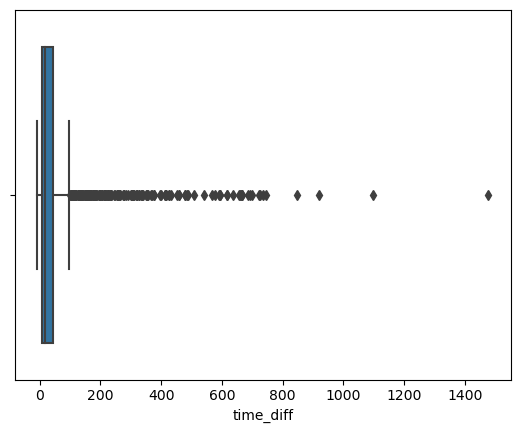

In [229]:
sns.boxplot(x='time_diff', data=df_ttid_1)

In [230]:
Q1 = df_ttid_1['time_diff'].quantile(0.25)
Q3 = df_ttid_1['time_diff'].quantile(0.75)

IQR = Q3 - Q1
LL = Q1 - 1.5 * IQR
UL = Q3 + 1.5 * IQR

print(f"Q1: {Q1} | Q3: {Q3} | IQR: {IQR} | LL: {LL} | UL: {UL}")

Q1: 9.05 | Q3: 44.55 | IQR: 35.5 | LL: -44.2 | UL: 97.8


In [231]:
outlier_count = df_ttid_1[df_ttid_1['time_diff'] > 97.8].shape[0]

outlier_perc = (outlier_count * 100)/df_ttid_1.shape[0]

print(f"no. of outliers: {outlier_count} | % of Outliers: {outlier_perc}")

no. of outliers: 219 | % of Outliers: 13.782252989301448


In [232]:
df_ttid_1['booking_nature'] = pd.cut(df_ttid_1['time_diff'],bins=[-8,9,17,45,1500], labels=['Urgent','SameDay','Regular','Advanced'])
df_ttid_1.head()

,online_booking,mobile_site_booking,Car_Cancellation,is_VMID_12,from_area_id_cancellation,city_route_cancellation,Month,Day_of_Week,is_weekend,Time of Day,time_diff,booking_nature
6,0,0,0,1,3,3,1,1,0,1,0.400000,Urgent
17,1,0,0,0,4,3,1,5,1,1,259.716667,Advanced
24,0,0,0,0,4,3,1,5,1,1,89.833333,Advanced
158,1,0,0,0,4,4,1,4,0,1,21.183333,Regular
216,1,0,0,0,4,3,1,6,1,1,45.966667,Advanced


In [233]:
df_ttid_1 = df_ttid_1.drop('time_diff',axis=1)
df_ttid_1['booking_nature'] = df_ttid_1['booking_nature'].map({'Urgent':1,'SameDay':2,'Regular':3,'Advanced':4})
df_ttid_1.head()

,online_booking,mobile_site_booking,Car_Cancellation,is_VMID_12,from_area_id_cancellation,city_route_cancellation,Month,Day_of_Week,is_weekend,Time of Day,booking_nature
6,0,0,0,1,3,3,1,1,0,1,1
17,1,0,0,0,4,3,1,5,1,1,4
24,0,0,0,0,4,3,1,5,1,1,4
158,1,0,0,0,4,4,1,4,0,1,3
216,1,0,0,0,4,3,1,6,1,1,4


In [234]:
df_ttid_1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1589 entries, 6 to 43407
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   online_booking             1589 non-null   int64   
 1   mobile_site_booking        1589 non-null   int64   
 2   Car_Cancellation           1589 non-null   int64   
 3   is_VMID_12                 1589 non-null   int32   
 4   from_area_id_cancellation  1589 non-null   int64   
 5   city_route_cancellation    1589 non-null   int64   
 6   Month                      1589 non-null   int32   
 7   Day_of_Week                1589 non-null   int32   
 8   is_weekend                 1589 non-null   int32   
 9   Time of Day                1519 non-null   category
 10  booking_nature             1589 non-null   category
dtypes: category(2), int32(4), int64(5)
memory usage: 102.8 KB


In [235]:
df_ttid_1['Time of Day'] = pd.to_numeric(df_ttid_1['Time of Day'],errors='coerce')

In [236]:
df_ttid_1['Time of Day'] = df_ttid_1['Time of Day'].fillna(df_ttid_1['Time of Day'].median())

In [237]:
df_ttid_1['Time of Day'] = df_ttid_1['Time of Day'].astype('int')
df_ttid_1['booking_nature'] = df_ttid_1['booking_nature'].astype('int')
df_ttid_1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1589 entries, 6 to 43407
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   online_booking             1589 non-null   int64
 1   mobile_site_booking        1589 non-null   int64
 2   Car_Cancellation           1589 non-null   int64
 3   is_VMID_12                 1589 non-null   int32
 4   from_area_id_cancellation  1589 non-null   int64
 5   city_route_cancellation    1589 non-null   int64
 6   Month                      1589 non-null   int32
 7   Day_of_Week                1589 non-null   int32
 8   is_weekend                 1589 non-null   int32
 9   Time of Day                1589 non-null   int32
 10  booking_nature             1589 non-null   int32
dtypes: int32(6), int64(5)
memory usage: 111.7 KB


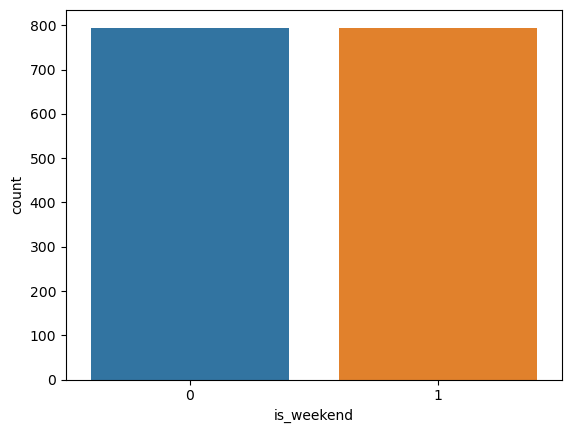

In [238]:
sns.countplot(x='is_weekend',data = df_ttid_1)
plt.show()

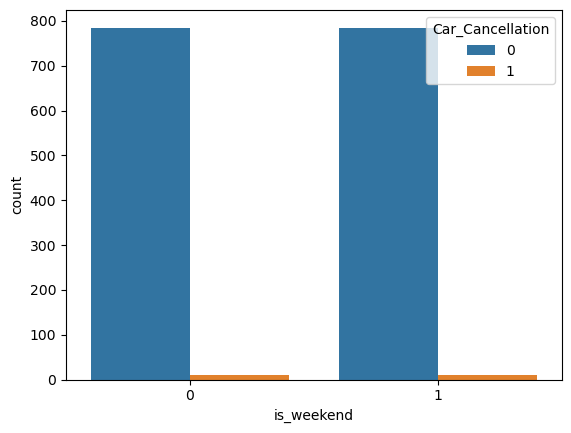

In [239]:
sns.countplot(x='is_weekend',hue= "Car_Cancellation",data = df_ttid_1)
plt.show()

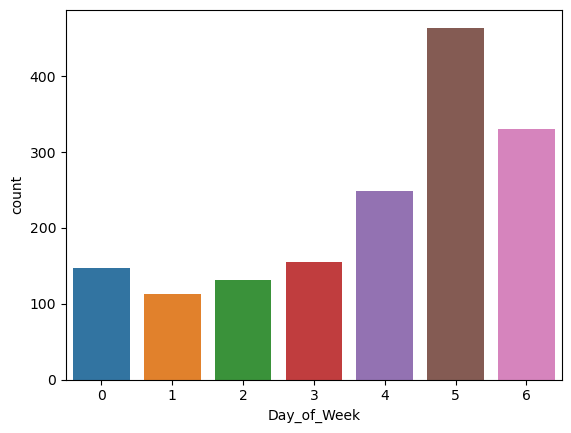

In [240]:
sns.countplot(x='Day_of_Week',data = df_ttid_1)
plt.show()

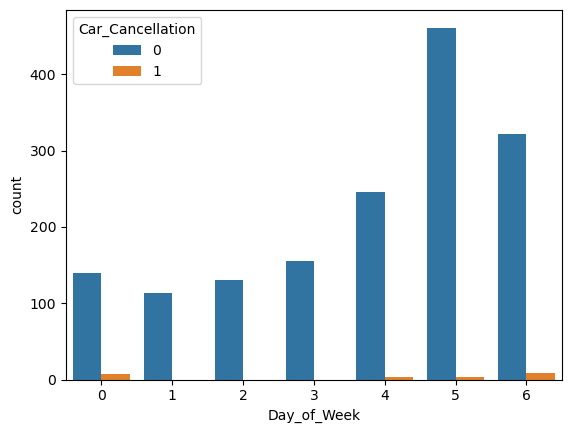

In [241]:
sns.countplot(x='Day_of_Week',hue= "Car_Cancellation",data = df_ttid_1)
plt.show()

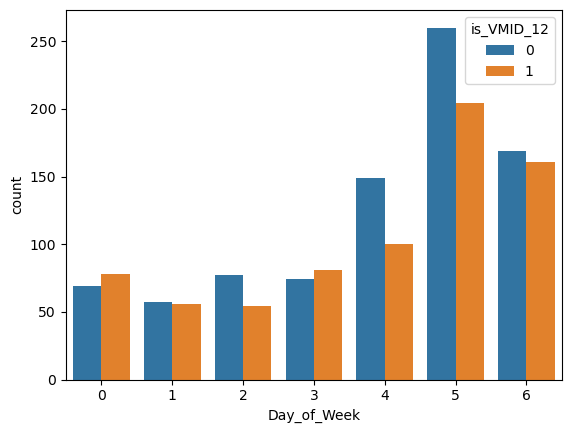

In [242]:
sns.countplot(x='Day_of_Week',hue= "is_VMID_12",data = df_ttid_1)
plt.show()

In [243]:
df_ttid_1.columns

Index(['online_booking', 'mobile_site_booking', 'Car_Cancellation',
       'is_VMID_12', 'from_area_id_cancellation', 'city_route_cancellation',
       'Month', 'Day_of_Week', 'is_weekend', 'Time of Day', 'booking_nature'],
      dtype='object')

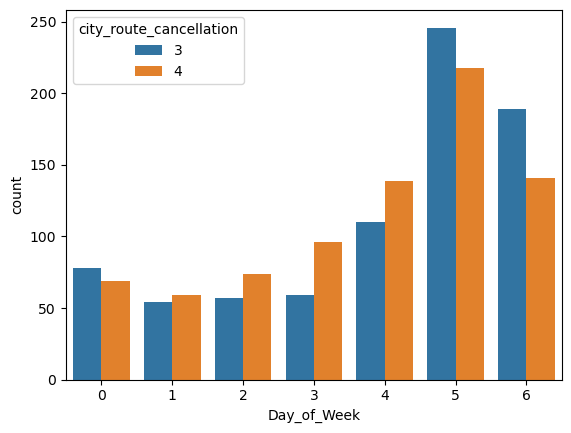

In [244]:
sns.countplot(x='Day_of_Week',hue= "city_route_cancellation",data = df_ttid_1)
plt.show()

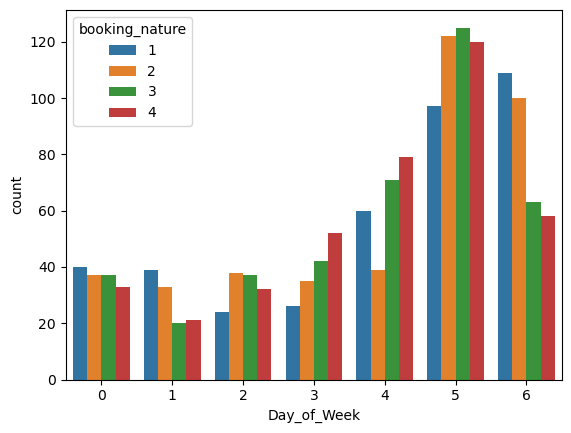

In [245]:
sns.countplot(x='Day_of_Week',hue= "booking_nature",data = df_ttid_1)
plt.show()

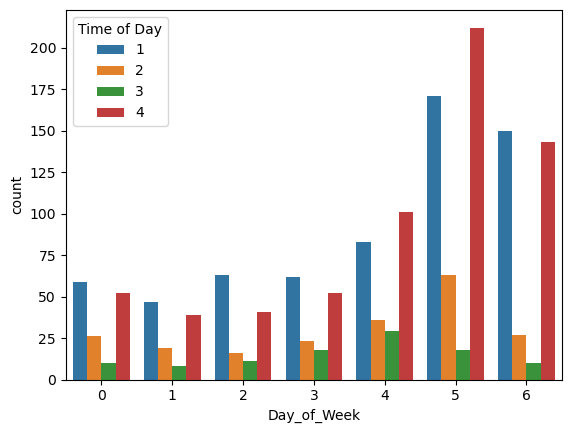

In [246]:
sns.countplot(x='Day_of_Week',hue= "Time of Day",data = df_ttid_1)
plt.show()

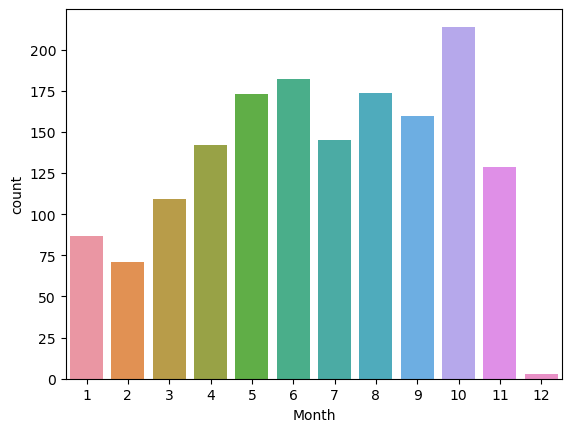

In [247]:
sns.countplot(x='Month',data = df_ttid_1)
plt.show()

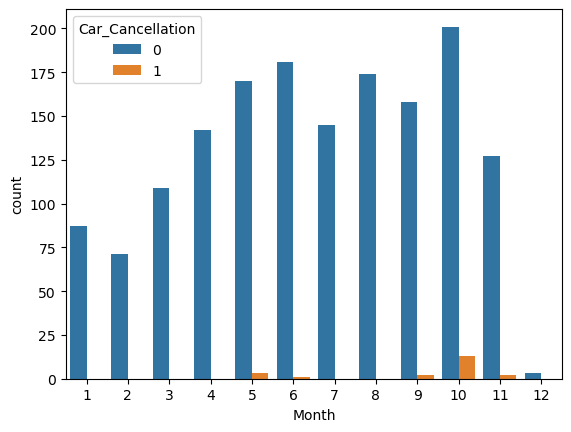

In [248]:
sns.countplot(x='Month',hue= "Car_Cancellation",data = df_ttid_1)
plt.show()

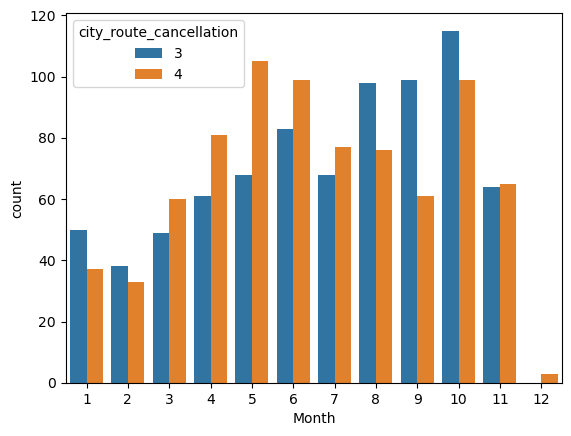

In [249]:
sns.countplot(x='Month',hue= "city_route_cancellation",data = df_ttid_1)
plt.show()

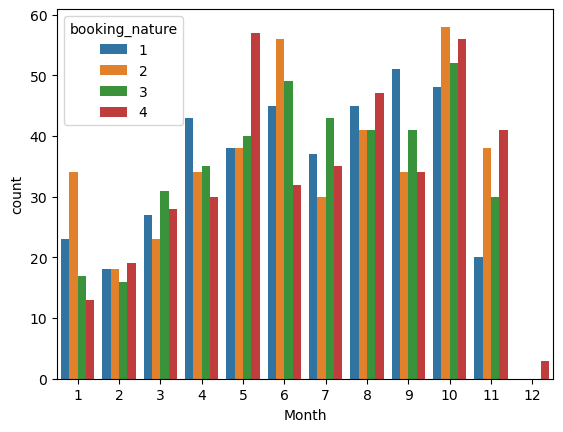

In [250]:
sns.countplot(x='Month',hue= "booking_nature",data = df_ttid_1)
plt.show()

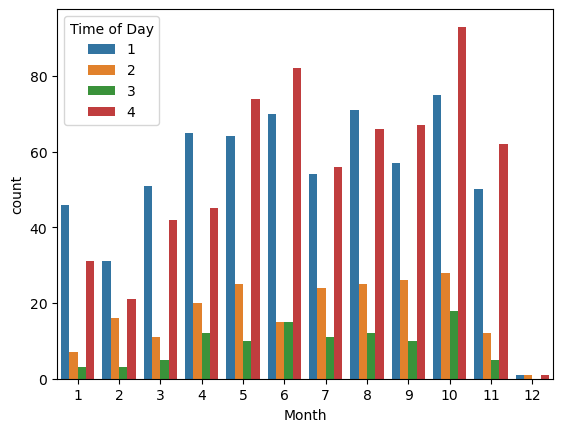

In [251]:
sns.countplot(x='Month',hue= "Time of Day",data = df_ttid_1)
plt.show()

In [252]:
df_ttid_1.head()

,online_booking,mobile_site_booking,Car_Cancellation,is_VMID_12,from_area_id_cancellation,city_route_cancellation,Month,Day_of_Week,is_weekend,Time of Day,booking_nature
6,0,0,0,1,3,3,1,1,0,1,1
17,1,0,0,0,4,3,1,5,1,1,4
24,0,0,0,0,4,3,1,5,1,1,4
158,1,0,0,0,4,4,1,4,0,1,3
216,1,0,0,0,4,3,1,6,1,1,4


In [253]:
X = df_ttid_1.drop(['Car_Cancellation'], axis =1)

In [254]:
X.head()

,online_booking,mobile_site_booking,is_VMID_12,from_area_id_cancellation,city_route_cancellation,Month,Day_of_Week,is_weekend,Time of Day,booking_nature
6,0,0,1,3,3,1,1,0,1,1
17,1,0,0,4,3,1,5,1,1,4
24,0,0,0,4,3,1,5,1,1,4
158,1,0,0,4,4,1,4,0,1,3
216,1,0,0,4,3,1,6,1,1,4


In [255]:
X.shape

(1589, 10)

In [256]:
Y = df_ttid_1['Car_Cancellation']
Y.head()

6      0
17     0
24     0
158    0
216    0
Name: Car_Cancellation, dtype: int64

In [257]:
Y.shape

(1589,)

In [258]:
Y.value_counts()

Car_Cancellation
0    1568
1      21
Name: count, dtype: int64

In [259]:
from sklearn.model_selection import train_test_split

xtrain, xtest, ytrain, ytest = train_test_split(X,Y,test_size=0.2,random_state=42)

In [260]:
xtrain.head()

,online_booking,mobile_site_booking,is_VMID_12,from_area_id_cancellation,city_route_cancellation,Month,Day_of_Week,is_weekend,Time of Day,booking_nature
33356,1,0,0,3,3,9,4,0,1,4
19051,1,0,0,3,4,6,4,0,1,3
41574,1,0,1,3,4,11,6,1,4,3
13949,1,0,0,3,4,5,5,1,1,3
27517,0,0,1,3,3,8,1,0,4,2


In [261]:
ytrain.head()

33356    0
19051    0
41574    0
13949    0
27517    0
Name: Car_Cancellation, dtype: int64

In [262]:
xtest.head()

,online_booking,mobile_site_booking,is_VMID_12,from_area_id_cancellation,city_route_cancellation,Month,Day_of_Week,is_weekend,Time of Day,booking_nature
30407,0,0,0,4,4,9,0,0,4,4
11409,0,0,0,3,4,4,6,1,1,1
40927,0,1,1,4,4,11,6,1,4,2
8100,0,0,0,4,3,3,4,0,4,3
16883,0,0,1,4,4,6,3,0,4,3


In [263]:
ytest.head()

30407    0
11409    0
40927    0
8100     0
16883    0
Name: Car_Cancellation, dtype: int64

In [264]:
xtrain.shape

(1271, 10)

In [265]:
ytrain.shape

(1271,)

In [266]:
ytrain.value_counts()

Car_Cancellation
0    1253
1      18
Name: count, dtype: int64

In [267]:
from sklearn.linear_model import LogisticRegression

In [268]:
log_reg = LogisticRegression()

In [269]:
log_reg.fit(xtrain,ytrain)

LogisticRegression()

In [270]:
y_pred = log_reg.predict(xtest)

In [271]:
from sklearn.metrics import confusion_matrix
conf_matrix=confusion_matrix(ytest,y_pred)
conf_matrix

array([[315,   0],
       [  2,   1]], dtype=int64)

In [272]:
log_reg.score(xtrain,ytrain)

0.9866247049567269

In [273]:
log_reg.score(xtest,ytest)

0.9937106918238994

In [274]:
from sklearn import metrics
print(metrics.classification_report(ytest,y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       315
           1       1.00      0.33      0.50         3

    accuracy                           0.99       318
   macro avg       1.00      0.67      0.75       318
weighted avg       0.99      0.99      0.99       318



In [275]:
from imblearn.over_sampling import SMOTE
sm = SMOTE(random_state=11)


In [276]:
x_over,y_over = sm.fit_resample(xtrain,ytrain)

In [277]:
print(x_over.shape)
print(y_over.shape)

(2506, 10)
(2506,)


In [278]:
y_over.value_counts()

Car_Cancellation
0    1253
1    1253
Name: count, dtype: int64

In [279]:
#pip install scikit-learn==1.2.2

In [280]:
log_reg.fit(x_over,y_over)

LogisticRegression()

In [281]:
y_pred = log_reg.predict(xtest)

In [282]:
conf_matrix=confusion_matrix(ytest,y_pred)
conf_matrix

array([[306,   9],
       [  2,   1]], dtype=int64)

In [283]:
log_reg.score(xtrain,ytrain)

0.959087332808812

In [284]:
log_reg.score(xtest,ytest)

0.9654088050314465

In [285]:
print(metrics.classification_report(ytest,y_pred))

              precision    recall  f1-score   support

           0       0.99      0.97      0.98       315
           1       0.10      0.33      0.15         3

    accuracy                           0.97       318
   macro avg       0.55      0.65      0.57       318
weighted avg       0.99      0.97      0.97       318



In [286]:
Y.value_counts()

Car_Cancellation
0    1568
1      21
Name: count, dtype: int64

In [287]:
X.shape

(1589, 10)

In [288]:
from imblearn.over_sampling import SMOTE
sm = SMOTE(random_state=11)
x_new,y_new = sm.fit_resample(X,Y)

In [289]:
y_new.value_counts()

Car_Cancellation
0    1568
1    1568
Name: count, dtype: int64

In [290]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x_new,y_new,test_size=0.2,random_state=7)

In [291]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(2508, 10)
(628, 10)
(2508,)
(628,)


In [292]:
from sklearn.preprocessing import RobustScaler
rs=RobustScaler()
x_train = rs.fit_transform(x_train)   #fit generates the parameters, transform applies 
x_test = rs.transform(x_test)

In [293]:
log_reg=LogisticRegression()
log_reg.fit(x_train,y_train)
y_pred_test=log_reg.predict(x_test)
y_pred_train=log_reg.predict(x_train)


In [294]:
conf_matrix=confusion_matrix(y_test,y_pred_test)
conf_matrix

array([[305,  17],
       [ 12, 294]], dtype=int64)

In [295]:
log_reg.score(x_train,y_train)

0.9605263157894737

In [296]:
log_reg.score(x_test,y_test)

0.9538216560509554

In [297]:
print(metrics.classification_report(y_test,y_pred_test))

              precision    recall  f1-score   support

           0       0.96      0.95      0.95       322
           1       0.95      0.96      0.95       306

    accuracy                           0.95       628
   macro avg       0.95      0.95      0.95       628
weighted avg       0.95      0.95      0.95       628



In [298]:
from sklearn.tree import DecisionTreeClassifier

In [299]:
dt_model = DecisionTreeClassifier()
dt_model.fit(xtrain,ytrain)

DecisionTreeClassifier()

In [300]:
dt_model.score(xtrain,ytrain)

0.998426435877262

In [301]:
dt_model.score(xtest,ytest)

0.9905660377358491

In [302]:
y_pred = dt_model.predict(xtest)
y_pred_train = dt_model.predict(xtrain)

In [303]:
print(metrics.classification_report(ytest,y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       315
           1       0.50      0.33      0.40         3

    accuracy                           0.99       318
   macro avg       0.75      0.67      0.70       318
weighted avg       0.99      0.99      0.99       318



In [304]:
print(metrics.classification_report(ytrain,y_pred_train))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1253
           1       1.00      0.89      0.94        18

    accuracy                           1.00      1271
   macro avg       1.00      0.94      0.97      1271
weighted avg       1.00      1.00      1.00      1271



In [305]:
dt_model.fit(x_over,y_over)

DecisionTreeClassifier()

In [306]:
y_pred = dt_model.predict(xtest)
y_pred_train = dt_model.predict(x_over)

In [307]:
print(metrics.classification_report(ytest,y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       315
           1       0.25      0.33      0.29         3

    accuracy                           0.98       318
   macro avg       0.62      0.66      0.64       318
weighted avg       0.99      0.98      0.99       318



In [308]:
print(metrics.classification_report(y_over,y_pred_train))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00      1253
           1       0.99      1.00      1.00      1253

    accuracy                           1.00      2506
   macro avg       1.00      1.00      1.00      2506
weighted avg       1.00      1.00      1.00      2506



In [309]:
dt_model.fit(x_train,y_train)

DecisionTreeClassifier()

In [310]:
y_pred = dt_model.predict(x_test)
y_pred_train = dt_model.predict(x_train)

In [311]:
print(metrics.classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       322
           1       0.99      0.99      0.99       306

    accuracy                           0.99       628
   macro avg       0.99      0.99      0.99       628
weighted avg       0.99      0.99      0.99       628



In [312]:
print(metrics.classification_report(y_train,y_pred_train))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1246
           1       1.00      1.00      1.00      1262

    accuracy                           1.00      2508
   macro avg       1.00      1.00      1.00      2508
weighted avg       1.00      1.00      1.00      2508



In [313]:
dt_model.score(x_train,y_train)

0.9968102073365231

In [314]:
dt_model.score(x_test,y_test)

0.9920382165605095

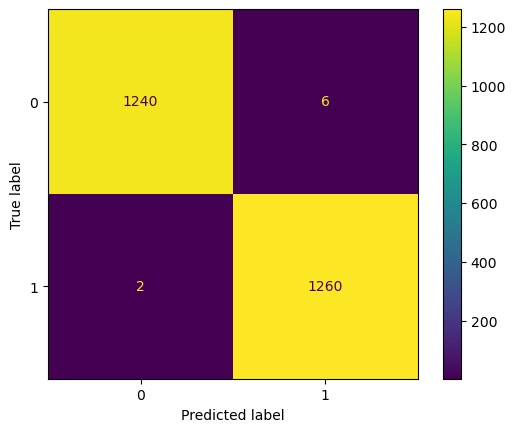

In [315]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(dt_model,x_train,y_train)
plt.show()

In [316]:
from sklearn.naive_bayes import GaussianNB

In [317]:
nb_model = GaussianNB()
nb_model.fit(xtrain,ytrain)

GaussianNB()

In [318]:
y_pred = nb_model.predict(xtest)
y_pred_train = nb_model.predict(xtrain)

In [319]:
print(metrics.classification_report(ytest,y_pred))

              precision    recall  f1-score   support

           0       1.00      0.82      0.90       315
           1       0.03      0.67      0.06         3

    accuracy                           0.82       318
   macro avg       0.52      0.74      0.48       318
weighted avg       0.99      0.82      0.89       318



In [320]:
print(metrics.classification_report(ytrain,y_pred_train))

              precision    recall  f1-score   support

           0       1.00      0.80      0.89      1253
           1       0.07      1.00      0.12        18

    accuracy                           0.80      1271
   macro avg       0.53      0.90      0.51      1271
weighted avg       0.99      0.80      0.88      1271



In [321]:
nb_model.fit(x_over,y_over)

GaussianNB()

In [322]:
y_pred = nb_model.predict(xtest)
y_pred_train = nb_model.predict(x_over)

In [323]:
print(metrics.classification_report(ytest,y_pred))

              precision    recall  f1-score   support

           0       1.00      0.82      0.90       315
           1       0.03      0.67      0.07         3

    accuracy                           0.82       318
   macro avg       0.52      0.74      0.48       318
weighted avg       0.99      0.82      0.89       318



In [324]:
print(metrics.classification_report(y_over,y_pred_train))

              precision    recall  f1-score   support

           0       1.00      0.81      0.89      1253
           1       0.84      1.00      0.91      1253

    accuracy                           0.90      2506
   macro avg       0.92      0.90      0.90      2506
weighted avg       0.92      0.90      0.90      2506



In [325]:
nb_model.score(x_over,y_over)

0.9034317637669593

In [326]:
nb_model.score(xtest,ytest)

0.8207547169811321

In [327]:
nb_model.fit(x_train,y_train)

GaussianNB()

In [328]:
y_pred = nb_model.predict(x_test)
y_pred_train = nb_model.predict(x_train)

In [329]:
print(metrics.classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      0.54      0.70       322
           1       0.68      1.00      0.81       306

    accuracy                           0.77       628
   macro avg       0.84      0.77      0.76       628
weighted avg       0.84      0.77      0.75       628



In [330]:
print(metrics.classification_report(y_train,y_pred_train))

              precision    recall  f1-score   support

           0       1.00      0.56      0.72      1246
           1       0.70      1.00      0.82      1262

    accuracy                           0.78      2508
   macro avg       0.85      0.78      0.77      2508
weighted avg       0.85      0.78      0.77      2508



In [331]:
from sklearn.ensemble import RandomForestClassifier

In [332]:
rf_model = RandomForestClassifier()
rf_model.fit(xtrain,ytrain)

RandomForestClassifier()

In [333]:
y_pred = rf_model.predict(xtest)
y_pred_train = rf_model.predict(xtrain)

In [334]:
print(metrics.classification_report(ytest,y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       315
           1       1.00      0.33      0.50         3

    accuracy                           0.99       318
   macro avg       1.00      0.67      0.75       318
weighted avg       0.99      0.99      0.99       318



In [335]:
print(metrics.classification_report(ytrain,y_pred_train))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1253
           1       0.94      0.94      0.94        18

    accuracy                           1.00      1271
   macro avg       0.97      0.97      0.97      1271
weighted avg       1.00      1.00      1.00      1271



In [336]:
rf_model = RandomForestClassifier()
rf_model.fit(x_over,y_over)

RandomForestClassifier()

In [337]:
y_pred = rf_model.predict(xtest)
y_pred_train = rf_model.predict(x_over)

In [338]:
print(metrics.classification_report(ytest,y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       315
           1       0.20      0.33      0.25         3

    accuracy                           0.98       318
   macro avg       0.60      0.66      0.62       318
weighted avg       0.99      0.98      0.98       318



In [339]:
print(metrics.classification_report(y_over,y_pred_train))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00      1253
           1       0.99      1.00      1.00      1253

    accuracy                           1.00      2506
   macro avg       1.00      1.00      1.00      2506
weighted avg       1.00      1.00      1.00      2506



In [340]:
rf_model = RandomForestClassifier()
rf_model.fit(x_train,y_train)

RandomForestClassifier()

In [341]:
y_pred = rf_model.predict(x_test)
y_pred_train = rf_model.predict(x_train)

In [342]:
print(metrics.classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       322
           1       0.99      0.99      0.99       306

    accuracy                           0.99       628
   macro avg       0.99      0.99      0.99       628
weighted avg       0.99      0.99      0.99       628



In [343]:
print(metrics.classification_report(y_train,y_pred_train))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1246
           1       1.00      1.00      1.00      1262

    accuracy                           1.00      2508
   macro avg       1.00      1.00      1.00      2508
weighted avg       1.00      1.00      1.00      2508



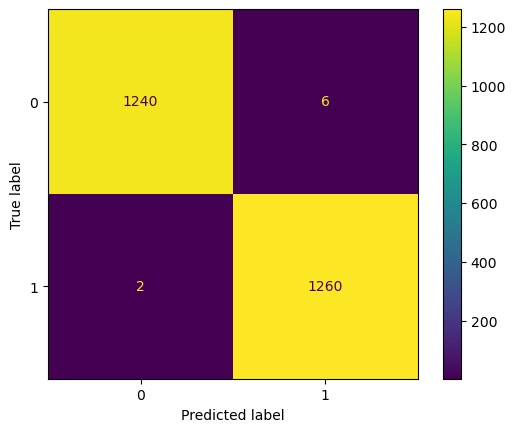

In [344]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(rf_model,x_train,y_train)
plt.show()

In [345]:
rf_model.score(x_train,y_train)

0.9968102073365231

In [346]:
rf_model.score(x_test,y_test)

0.9936305732484076

In [348]:
rf_model = RandomForestClassifier()
rf_model.fit(x_train,y_train)

RandomForestClassifier()

In [349]:
from sklearn.model_selection import train_test_split, GridSearchCV

In [351]:
param_dist = {'max_depth': [2, 3, 4,6,8,10],
              'max_features': ['auto', 'sqrt'],
             'n_estimators':[10,15,20,25,30]}

cv_rf = GridSearchCV(rf_model, cv =10,
                     param_grid=param_dist)

cv_rf.fit(x_train, y_train)

print('Best Parameters using grid search: \n', cv_rf.best_params_)

Best Parameters using grid search: 
 {'max_depth': 10, 'max_features': 'auto', 'n_estimators': 30}


In [352]:
y_pred = cv_rf.predict(x_test)
print(metrics.classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99       322
           1       0.99      1.00      0.99       306

    accuracy                           0.99       628
   macro avg       0.99      0.99      0.99       628
weighted avg       0.99      0.99      0.99       628



In [354]:
y_pred_train = cv_rf.predict(x_train)
print(metrics.classification_report(y_train,y_pred_train))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00      1246
           1       0.99      1.00      1.00      1262

    accuracy                           1.00      2508
   macro avg       1.00      1.00      1.00      2508
weighted avg       1.00      1.00      1.00      2508



In [355]:
from sklearn.model_selection import cross_val_score

scores=cross_val_score(cv_rf,X,Y,cv=15)
scores.mean()

0.9867864630128783

In [357]:
y_pred = dt_model.predict(x_test)
y_pred_train = dt_model.predict(x_train)

In [362]:
param_dist = {'max_depth': [2, 3, 4,5,6,7,8,9,10],
              'criterion': ['gini', 'entropy'],
             'max_leaf_nodes':[4,6,8,10,12,14]}

cv_dt = GridSearchCV(dt_model, cv = 15,
                     param_grid=param_dist)

cv_dt.fit(x_train, y_train)

print(cv_dt.best_score_)

print('Best Parameters using grid search: \n', cv_rf.best_params_)

0.9844572759243418
Best Parameters using grid search: 
 {'max_depth': 10, 'max_features': 'auto', 'n_estimators': 30}


In [360]:
y_pred = cv_dt.predict(x_test)
print(metrics.classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.99      0.98      0.98       322
           1       0.98      0.99      0.98       306

    accuracy                           0.98       628
   macro avg       0.98      0.98      0.98       628
weighted avg       0.98      0.98      0.98       628



In [361]:
y_pred_train = cv_dt.predict(x_train)
print(metrics.classification_report(y_train,y_pred_train))

              precision    recall  f1-score   support

           0       0.99      0.98      0.99      1246
           1       0.98      0.99      0.99      1262

    accuracy                           0.99      2508
   macro avg       0.99      0.99      0.99      2508
weighted avg       0.99      0.99      0.99      2508



In [363]:
from sklearn.model_selection import cross_val_score

scores=cross_val_score(cv_dt,X,Y,cv=15)
scores.mean()

0.9886552860137766